# Incisos del 5 al 8.

### Importación de librerías.

In [1]:
import pickle
from networkx.algorithms import bipartite
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

### Importando la red bipartita.

In [2]:
with open("red_bipartita.pkl", "rb") as f:
    G = pickle.load(f)

## Inciso 5.

### 5.1) Proyección autor-autor.

In [3]:
# Nodos autores.
autores = [nodo for nodo, datos in G.nodes(data=True) if datos["tipo"] == "autor"]

# Proyección autor-autor. El peso representa el número de videos compartidos.
G_autores = bipartite.weighted_projected_graph(G, autores)

print("Nodos:", G_autores.number_of_nodes())
print("Aristas:", G_autores.number_of_edges())

Nodos: 332
Aristas: 10732


In [4]:
list(G_autores.edges(data=True))[:2]

[('autor::UCdFlugHJJa4l3YqWuNRmvXw',
  'autor::UC1DpqK6vaPEkBOMNvypsKYg',
  {'weight': 1}),
 ('autor::UCdFlugHJJa4l3YqWuNRmvXw',
  'autor::UC32oozucwCF3q8d4m8fyOUg',
  {'weight': 1})]

### 5.2) Proyección video-video.

In [5]:
# Nodos videos.
videos_grafo = [nodo for nodo, datos in G.nodes(data=True) if datos["tipo"] == "video"]

# Proyección video-video. El peso representa el número de autores compartidos.
G_videos = bipartite.weighted_projected_graph(G, videos_grafo)

print("Nodos:", G_videos.number_of_nodes())
print("Aristas:", G_videos.number_of_edges())

Nodos: 19
Aristas: 11


In [6]:
list(G_videos.edges(data=True))[:2]

[('video::06mFNPU0aB8', 'video::6W4u8sGEnGM', {'weight': 1}),
 ('video::6W4u8sGEnGM', 'video::PjmxCj-a9Hg', {'weight': 1})]

### Comparando las dos proyecciones.

In [7]:
comparacion = pd.DataFrame({
    "red": ["Autor-Autor", "Video-Video"],
    "nodos": [G_autores.number_of_nodes(), G_videos.number_of_nodes()],
    "aristas": [G_autores.number_of_edges(), G_videos.number_of_edges()],
    "densidad": [nx.density(G_autores), nx.density(G_videos)]
})

comparacion

,red,nodos,aristas,densidad
0,Autor-Autor,332,10732,0.195319
1,Video-Video,19,11,0.064327


Autor–autor: Representa si dos autores están relacionados por comentar el mismo contenido; no significa amistad ni interacción directa.

Video–video: Representa si dos videos se relacionan cuando al menos un mismo autor comentó en ambos.

Una mayor densidad en la red autor–autor indicaría mayor coincidencia entre videos en los que comentan autores. Una mayor densidad video–video indicaría similitudes de audiencias entre videos.

### 5.4) Visualizando las proyecciones.

#### Proyección autor-autor.

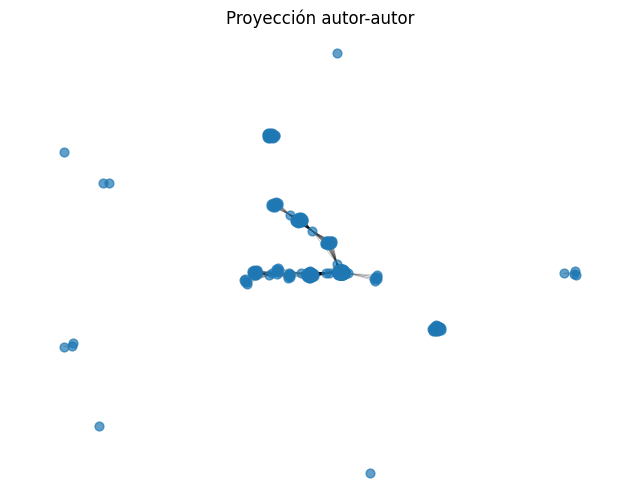

In [8]:
pos_autores = nx.spring_layout(G_autores, seed=42, weight="weight")
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_autores, pos_autores, node_size=40, alpha=0.7)
nx.draw_networkx_edges(G_autores, pos_autores, width=0.5, alpha=0.25)
plt.title("Proyección autor-autor")
plt.axis("off")
plt.show()

Podemos observar que hay una gra cantidad de autores que es posible que sean comentadore de un tipo de contenido de masas, lo cual representa la alta acumulación de en medio, mientras que hay otros que comentan en videos un poco más de nicho.

#### Proyección video-video.

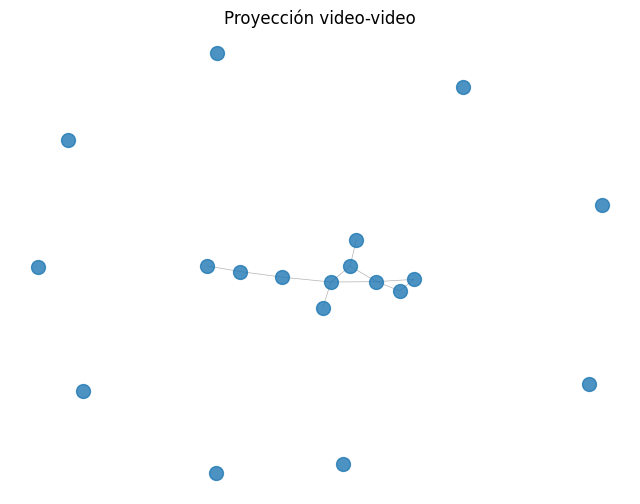

In [9]:
pos_videos = nx.spring_layout(G_videos, seed=42, weight="weight")
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_videos, pos_videos, node_size=100, alpha=0.8)
nx.draw_networkx_edges(G_videos, pos_videos, width=0.5, alpha=0.3)
plt.title("Proyección video-video")
plt.axis("off")
plt.show()

Lod videos del centro pueden estar relacionados por el tipo de contenido.

## Inciso 6.

### 6.1) Topología y fragmentación.

#### Métricas de la red.

In [11]:
def metricas_red(G, nombre):
    grados = dict(G.degree())
    componentes = list(nx.connected_components(G))
    componente_mayor = max(componentes, key=len)
    return {
        "red": nombre,
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "densidad": nx.density(G),
        "grado_medio": sum(grados.values()) / G.number_of_nodes(),
        "componentes": len(componentes),
        "componente_mayor": len(componente_mayor)
    }

metricas = pd.DataFrame([
    metricas_red(G, "Bipartita"),
    metricas_red(G_autores, "Autor-Autor"),
    metricas_red(G_videos, "Video-Video")
])

metricas

,red,nodos,aristas,densidad,grado_medio,componentes,componente_mayor
0,Bipartita,351,343,0.005584,1.954416,10,286
1,Autor-Autor,332,10732,0.195319,64.650602,10,276
2,Video-Video,19,11,0.064327,1.157895,10,10


La bipartita, como es de esperar, tiene la mayor cantidad de nodos, pero como se observa en la tabla, estos en su gran mayoría son de autores que comentan videos.  
La mayor cantidad de aristas lo tiene la red de autor-autor, debido a la alta cantidad de nodos y que estos se pueden conectar con el simple hecho de haber comentado sobre un mismo video, debido a la alta cantidad de aristas, también posee la mayor densidad y grado medio de todas.  
Todas las redes tienen 10 componentes, lo cual tiene sentido, teniendo en cuenta que se forma conjuntos aislados por la forma en que se relacionan videos y autores, lo cual hace que en las proyecciones se mantengan dichas conjuntos.  
El componente más grande de Bipartita contiene al componente más grande de Autor-Autor y al componente más grande de Video-Video.

#### Graficar distribución de grados.

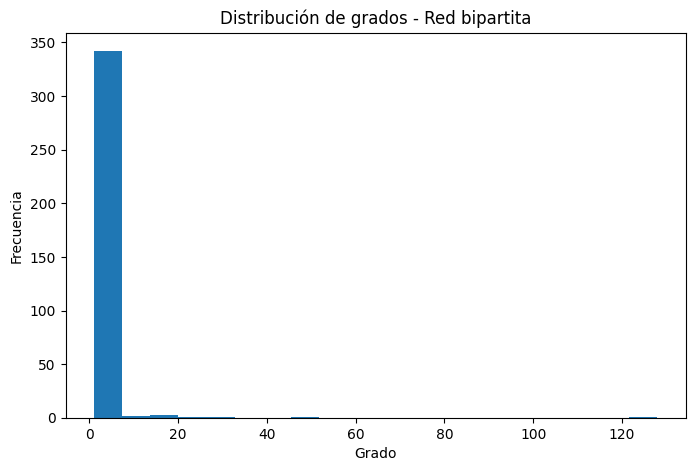

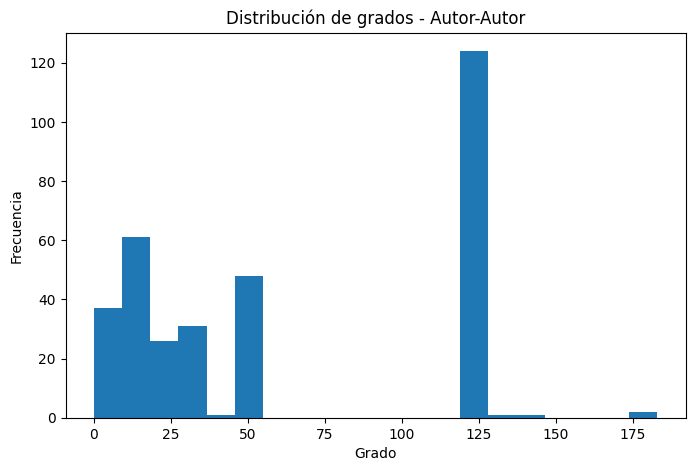

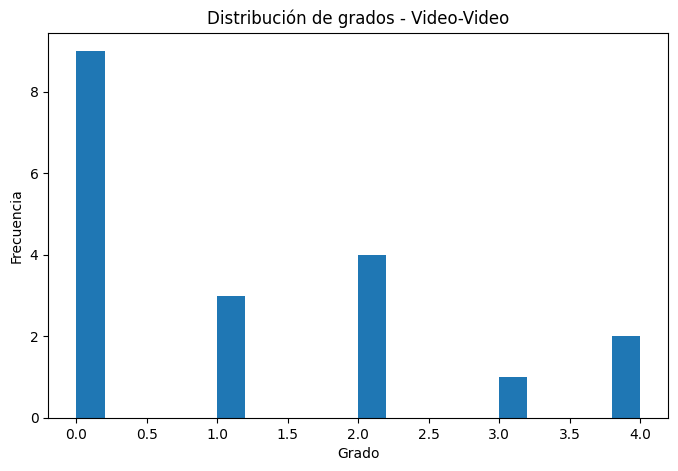

In [10]:
def graficar_grados(G, titulo):
    grados = [grado for _, grado in G.degree()]
    plt.figure(figsize=(8, 5))
    plt.hist(grados, bins=20)
    plt.xlabel("Grado")
    plt.ylabel("Frecuencia")
    plt.title(titulo)
    plt.show()

graficar_grados(G, "Distribución de grados - Red bipartita")
graficar_grados(G_autores, "Distribución de grados - Autor-Autor")
graficar_grados(G_videos, "Distribución de grados - Video-Video")

En la red Autor-Autor, sus nodos están muy conextados, mientras que en las otras, se tienen muy pocas conexiones.

#### Conexiones entre nodos.

In [12]:
def resumen_grados(G):
    grados = pd.Series(dict(G.degree()))
    return grados.describe()

print("Bipartita")
display(resumen_grados(G))
print("Autor-Autor")
display(resumen_grados(G_autores))
print("Video-Video")
display(resumen_grados(G_videos))

Bipartita


count    351.000000
mean       1.954416
std        7.716267
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      128.000000
dtype: float64

Autor-Autor


count    332.000000
mean      64.650602
std       51.832564
min        0.000000
25%       18.000000
50%       48.000000
75%      127.000000
max      183.000000
dtype: float64

Video-Video


count    19.000000
mean      1.157895
std       1.384965
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       4.000000
dtype: float64

Solo la red Autor-Autor tiene una alta cantidad de conexiones, teniendo hasta 18 conexiones en su primer cuartil.  
La red Video-Video, un poco menos de la mitad de sus nodos tiene al menos 2 conexiones.  
La red Bipartita, la gran mayoría de sus nodos solo tienen una conexión, pero hay nodos muy conectados (estos deberían ser videos).

### 6.2) Cohesión y transitividad.

In [13]:
def cohesion_transitividad(G, nombre):
    mayor = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    return {
        "red": nombre,
        "cohesion": nx.node_connectivity(mayor) if mayor.number_of_nodes() > 1 else 0,
        "transitividad": nx.transitivity(G)
    }

cohesion = pd.DataFrame([
    cohesion_transitividad(G, "Bipartita"),
    cohesion_transitividad(G_autores, "Autor-Autor"),
    cohesion_transitividad(G_videos, "Video-Video")
])

cohesion

,red,cohesion,transitividad
0,Bipartita,1,0.000000
1,Autor-Autor,1,0.984025
2,Video-Video,1,0.315789


Cohesión:  Qué tan fuertemente conectado está un grafo y qué tan difícil es fragmentarlo al eliminar componentes.  
Transitividad: Probabilidad de que dos nodos que comparten un vecino común también estén conectados entre sí.  
  
Todas las redes están a una conexión de perder una componente, esto se debe a que tienen componentes periféricos (se muestra en el siguiente inciso).  
La transitividad es mucho mayor en la red Autor-Autor, esto debido a su gran cantidad de conexiones, hace que la mayoría de nodos estén conectados entre sí. En la red Bipartita es 0, ya que es un requisito para ser bipartita. En la de video-video, solo cerca de 1/3 cumple con el criterio de transitividad.

### 6.3) Grupos periféricos y aislados.

In [15]:
def perifericos_aislados(G, nombre):
    aislados = list(nx.isolates(G))
    perifericos = [nodo for nodo, grado in G.degree() if grado == 1]
    print(nombre)
    print("Aislados:", len(aislados))
    print("Periféricos:", len(perifericos))
    return aislados, perifericos

aislados_bip, perifericos_bip = perifericos_aislados(G, "Bipartita")
print('--------------------')
aislados_autores, perifericos_autores = perifericos_aislados(G_autores, "Autor-Autor")
print('--------------------')
aislados_videos, perifericos_videos = perifericos_aislados(G_videos, "Video-Video")

Bipartita
Aislados: 0
Periféricos: 327
--------------------
Autor-Autor
Aislados: 4
Periféricos: 2
--------------------
Video-Video
Aislados: 9
Periféricos: 3


Aislados: No tienen conexiones.  
Periféricos: Solo tienen una conexión.  
  
En la red bipartita no pueden existir nodos aislados, la mayoría de sus nodos, en este caso son periféricos (327 de 351).

In [16]:
print("Autores aislados:", aislados_autores[:10])
print("Autores periféricos:", perifericos_autores[:10])
print("Videos aislados:", aislados_videos[:10])
print("Videos periféricos:", perifericos_videos[:10])

Autores aislados: ['autor::UCPLW0HE3siElqCgXfgWxMqg', 'autor::UCQM2tCKRRytVDRxNUfCDqQQ', 'autor::UC_NRVt2UP88ZNTwzrZ66JSg', 'autor::UC6xI_MOaxajIWpoP8BH6E_Q']
Autores periféricos: ['autor::UCJxJC56BSAX-ArD0NAb9qnQ', 'autor::UCyor0Mmm0ivLX2jIdyGp84Q']
Videos aislados: ['video::3Nfp9h5avBI', 'video::JkpVO1hx2f8', 'video::OkXlHx0hx-8', 'video::TT4qJ5FXHYE', 'video::UhL9y3KUl8E', 'video::X_FAIef8qlE', 'video::lj983NWyAQY', 'video::s0eco-BofOs', 'video::zweosulrwA8']
Videos periféricos: ['video::06mFNPU0aB8', 'video::b_Hkrkl3adA', 'video::is3Mk5oC19g']


Se muestran algunos id's de videos y autores que están aisaldos o son periféricos.  
El hecho de aparecer como aislados o periféricos no quiere decir que sea la realidad del autor o el video, solo que en el datos analizados, solo se cuentan con las conexiones que los hacen ser aislados o periféricos.

### 6.4) Hallazgos estructurales.

In [18]:
for nombre, red in [("Bipartita", G), ("Autor-Autor", G_autores), ("Video-Video", G_videos)]:
    grados = pd.Series(dict(red.degree()))
    print(nombre)
    print("Mediana:", grados.median())
    print("Máximo:", grados.max())
    print("Nodos grado 1:", (grados == 1).sum())
    print("Nodos grado 0:", (grados == 0).sum())
    print('----------------------------------')

Bipartita
Mediana: 1.0
Máximo: 128
Nodos grado 1: 327
Nodos grado 0: 0
----------------------------------
Autor-Autor
Mediana: 48.0
Máximo: 183
Nodos grado 1: 2
Nodos grado 0: 4
----------------------------------
Video-Video
Mediana: 1.0
Máximo: 4
Nodos grado 1: 3
Nodos grado 0: 9
----------------------------------


## Inciso 7.